In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 800
temp = np.random.normal(75, 10, n)
vibration = np.random.normal(2.5, 1.0, n)
pressure = np.random.normal(30, 5, n)
rpm = np.random.normal(3000, 400, n)
run_hours = np.random.uniform(0, 5000, n)

failure_score = (
    0.04*(temp-75) +
    0.8*(vibration-2.5) +
    0.0006*run_hours -
    np.random.normal(0,1,n)
)
failure = (failure_score > 1.2).astype(int)

sensor_df = pd.DataFrame({
    "temperature_C": temp,
    "vibration_mm_s": vibration,
    "pressure_psi": pressure,
    "rpm": rpm,
    "run_hours": run_hours,
    "failure": failure
})

print("Failure rate:", round(sensor_df["failure"].mean(), 3))
display(sensor_df.head())

Failure rate: 0.601


,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
0,79.967142,3.438284,29.085518,2711.304979,4672.165194,1
1,73.617357,1.983955,36.874382,3070.728349,3445.438269,1
2,81.476885,2.596121,26.770179,2781.327966,4116.366063,1
3,90.230299,2.037725,26.004040,2891.337956,2780.953463,0
4,72.658466,2.065504,27.586282,3669.380836,3897.583507,1


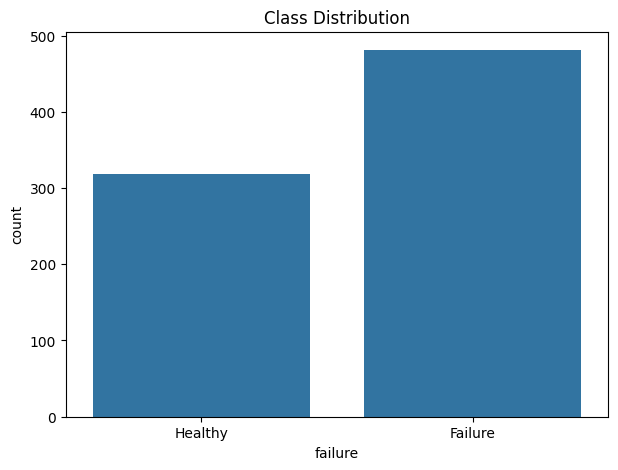

In [2]:
plt.figure(figsize=(7,5))
sns.countplot(x="failure", data=sensor_df)
plt.xticks([0,1], ["Healthy","Failure"])
plt.title("Class Distribution")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score
)

X = sensor_df.drop(columns="failure")
y = sensor_df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
clf.fit(X_train_s, y_train)

preds = clf.predict(X_test_s)
probs = clf.predict_proba(X_test_s)[:,1]

print(classification_report(y_test, preds, target_names=["Healthy","Failure"]))
print("Accuracy:", round(accuracy_score(y_test,preds), 3))

              precision    recall  f1-score   support

     Healthy       0.74      0.72      0.73        80
     Failure       0.82      0.83      0.83       120

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.79      0.79      0.79       200

Accuracy: 0.79


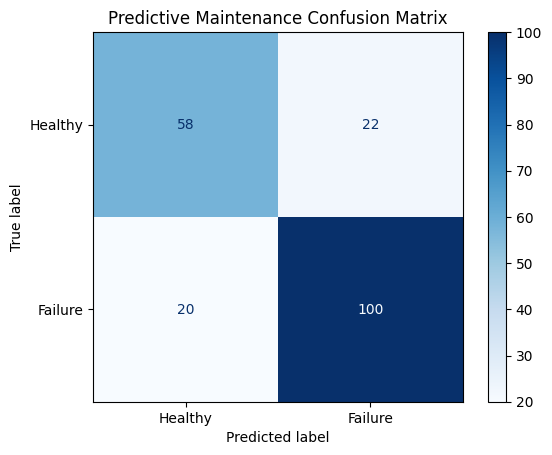

In [4]:
cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=["Healthy","Failure"]).plot(cmap="Blues")
plt.title("Predictive Maintenance Confusion Matrix")
plt.show()

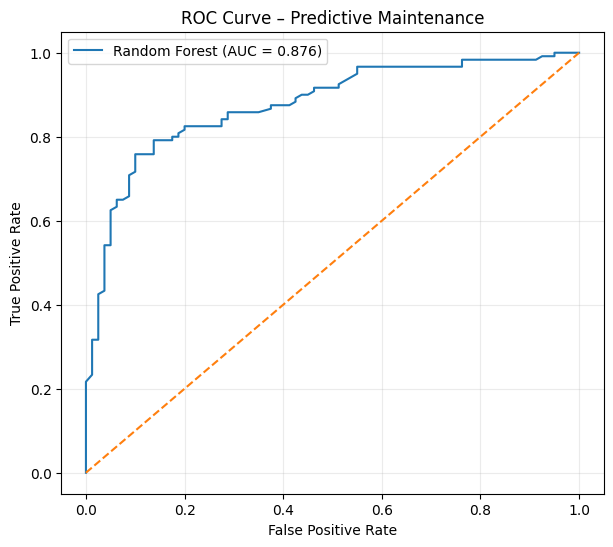

In [5]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Predictive Maintenance")
plt.legend()
plt.grid(alpha=.25)
plt.show()

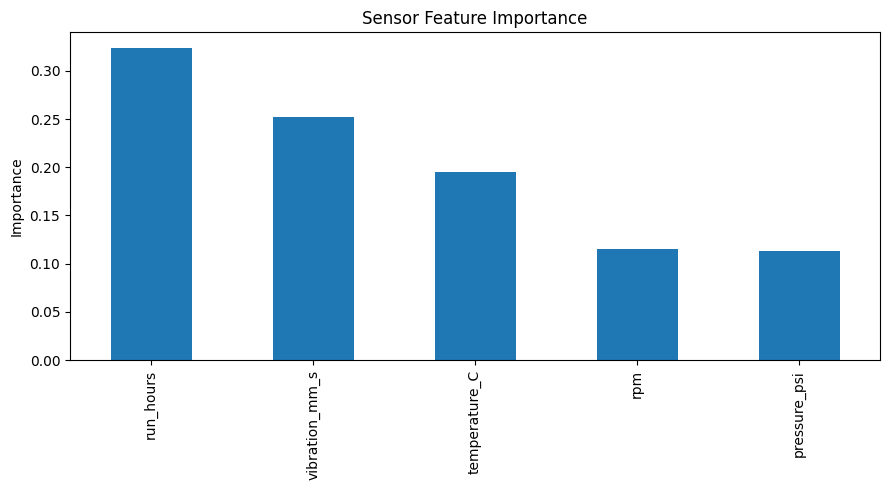

In [6]:
importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind="bar", figsize=(9,5), title="Sensor Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()